# Diginetica: Data cleaning, Exploratory Data Analysis and Feature engineering

## 1. Introduction and data loading

This notebook prepares the Diginetica dataset for two recommender systems that are built from scratch in a separate modelling notebook: matrix factorization (SVD, technique A) and item-based collaborative filtering (Item-KNN, technique D). Diginetica is an e-commerce dataset released for the CIKM Cup 2016, containing anonymized browsing and transaction logs.

In this notebook I clean the data, explore it, engineer the features needed for collaborative filtering, and save a single processed interaction file. That file is then loaded by the modelling notebook.

### 1.1 Extract and load the raw files

The dataset is downloaded from Kaggle as a zip archive. I extract it and load the three files that are relevant for collaborative filtering: the item views, the purchases, and the product catalog. The files are separated by semicolons, so `sep=';'` is set explicitly.

In [1]:
import zipfile, os

zip_name = "archive diginetica.zip"

with zipfile.ZipFile(zip_name) as z:
    z.extractall("diginetica")

print(os.listdir("diginetica"))

['product-categories.csv', 'products.csv', 'train-clicks.csv', 'train-item-views.csv', 'train-purchases.csv', 'train-queries.csv']


In [2]:
import pandas as pd

views     = pd.read_csv("diginetica/train-item-views.csv", sep=';')
purchases = pd.read_csv("diginetica/train-purchases.csv",  sep=';')
items     = pd.read_csv("diginetica/products.csv",          sep=';')

print("VIEWS:",     views.columns.tolist())
print(views.head(), "\n")
print("PURCHASES:", purchases.columns.tolist())
print(purchases.head(), "\n")
print("ITEMS:",     items.columns.tolist())
print(items.head())

VIEWS: ['sessionId', 'userId', 'itemId', 'timeframe', 'eventdate']
   sessionId  userId  itemId  timeframe   eventdate
0          1     NaN   81766     526309  2016-05-09
1          1     NaN   31331    1031018  2016-05-09
2          1     NaN   32118     243569  2016-05-09
3          1     NaN    9654      75848  2016-05-09
4          1     NaN   32627    1112408  2016-05-09 

PURCHASES: ['sessionId', 'userId', 'timeframe', 'eventdate', 'ordernumber', 'itemId']
   sessionId   userId   timeframe   eventdate  ordernumber  itemId
0        150  18278.0    17100868  2016-05-06        16421   25911
1        151      NaN     6454547  2016-05-06        16290  175874
2        156      7.0  1721689387  2016-05-27        21173   35324
3        179      NaN      343001  2016-05-09        16924   31233
4        246     34.0     2311046  2016-05-09        16936   34677 

ITEMS: ['itemId', 'pricelog2', 'product.name.tokens']
   itemId  pricelog2              product.name.tokens
0       1         10 

### 1.2 Clean the column names

The raw files use names like `sessionId` and `itemId`. I rename these to clear, consistent names (`session_id`, `item_id`, etc.) so the rest of the notebook is easier to read and matches the names used in the modelling notebook. This is the first cleaning step, done before the analysis so that all later code uses the same names.

In [3]:
# Rename the columns of all three tables to clear, consistent names.
views = views.rename(columns={'sessionId': 'session_id', 'userId': 'user_id', 'itemId': 'item_id', 'eventdate': 'date'})
purchases = purchases.rename(columns={'sessionId': 'session_id', 'userId': 'user_id','itemId': 'item_id', 'eventdate': 'date'})
items = items.rename(columns={'itemId': 'item_id', 'pricelog2': 'log2price','product.name.tokens': 'name_tokens'})

# Confirm the new column names.
print("Views:", views.columns.tolist())
print("Purchases:", purchases.columns.tolist())
print("Items:", items.columns.tolist())

Views: ['session_id', 'user_id', 'item_id', 'timeframe', 'date']
Purchases: ['session_id', 'user_id', 'timeframe', 'date', 'ordernumber', 'item_id']
Items: ['item_id', 'log2price', 'name_tokens']


## 2. Exploratory Data Analysis

In this section I explore the data before making any cleaning or modelling decisions. The goal is to understand the size of the data, the amount of missing values, the shape of the main distributions, and the relationships between item-level features. The findings here are used to justify the cleaning and filtering choices made later in the notebook.

### 2.1 Descriptive statistics

First, the raw tables are described to understand their size and shape. I focus on three things that matter for a recommender system: how many items a session interacts with (session length), how often each item is interacted with (item popularity), and the distribution of item price.

In [4]:
# Basic size of each table.
print("View records:", len(views))
print("Purchase records:", len(purchases))
print("Unique sessions (in views):", views['session_id'].nunique())
print("Unique items (in views):", views['item_id'].nunique())
print("Unique items (in catalog):", items['item_id'].nunique())

# Session length = how many items each session views.
session_length = views.groupby('session_id').size()
print("\nSession length (items per session):")
print(session_length.describe())

# Item popularity = how many times each item is viewed.
item_popularity = views.groupby('item_id').size()
print("\nItem popularity (views per item):")
print(item_popularity.describe())

# Price is already provided on a log2 scale in the catalog.
print("\nItem price (log2price):")
print(items['log2price'].describe())

View records: 1235380
Purchase records: 18025
Unique sessions (in views): 310324
Unique items (in views): 122993
Unique items (in catalog): 184047

Session length (items per session):
count    310324.000000
mean          3.980936
std           3.909900
min           1.000000
25%           1.000000
50%           3.000000
75%           5.000000
max          87.000000
dtype: float64

Item popularity (views per item):
count    122993.000000
mean         10.044311
std          28.272077
min           1.000000
25%           1.000000
50%           3.000000
75%           8.000000
max        1270.000000
dtype: float64

Item price (log2price):
count    184047.000000
mean          5.163839
std           3.678196
min           0.000000
25%           0.000000
50%           7.000000
75%           8.000000
max          15.000000
Name: log2price, dtype: float64


### Interpretation

The tables are large: there are 1,235,380 view records and 18,025 purchase records, spread over 310,324 sessions and 122,993 viewed items. The catalog itself contains 184,047 items, which is more than the number of items that were actually viewed, so a part of the catalog never appears in the browsing logs.

Session length is short on average: a session views about 4 items on average (mean 3.98), and the median is only 3. The minimum is 1 and the maximum is 87, so a few very long sessions exist but most are short. This confirms that each session gives only a small amount of information about preferences.

Item popularity is very uneven. The average item is viewed about 10 times (mean 10.04), but the median is only 3, while the maximum is far higher. This large gap between the median and the maximum is a first sign of a long-tail distribution, which is examined visually in section 2.3. Item price (log2price) ranges from 0 to 15, which is a narrow and stable range because the price is already on a log2 scale.

### 2.2 Missing values analysis

Next, I check each table for missing values. This matters because the way missing values are handled affects which records can be used. For each table I count the missing values per column.

In [5]:
# Count missing values per column for each table.
print("Missing values in views:")
print(views.isna().sum(), "\n")

print("Missing values in purchases:")
print(purchases.isna().sum(), "\n")

print("Missing values in items:")
print(items.isna().sum())

Missing values in views:
session_id         0
user_id       862389
item_id            0
timeframe          0
date               0
dtype: int64 

Missing values in purchases:
session_id         0
user_id        11322
timeframe          0
date               0
ordernumber        0
item_id            0
dtype: int64 

Missing values in items:
item_id        0
log2price      0
name_tokens    0
dtype: int64


### Interpretation

The only column with missing values is `user_id`. In the views table 862,389 of the 1,235,380 records have no user id (about 70%), and in the purchases table 11,322 of the 18,025 records are missing one. All other columns, including `session_id` and `item_id`, are complete in every table.

This is important for two reasons. First, the columns needed to build the interaction data (`session_id` and `item_id`) have no missing values, so no rows are lost there. Second, imputing the missing `user_id` is not appropriate: an anonymized user cannot be reconstructed without inventing information that is not in the data. The right response to this missingness is therefore not imputation but a change of unit, using the `session_id` instead of the `user_id` as the user. This choice is examined further in section 2.4.

In [6]:
# The userId column is the most important case of missing data, so I look at it separately. This share supports the later decision to use the session as the user unit.
print("Share of views with a known userId:",
      f"{views['user_id'].notna().mean():.2%}")
print("Number of view records:", len(views))
print("Number of purchase records:", len(purchases))

Share of views with a known userId: 30.19%
Number of view records: 1235380
Number of purchase records: 18025


### Interpretation

Only about 30% of the view records contain a known `userId`, so for roughly 70% of the views the user is anonymous. Imputing a user id is not appropriate here, because an anonymized user cannot be invented without introducing false information. Using `userId` as the user unit would therefore mean throwing away most of the data, which supports treating each `sessionId` as the user unit instead.

The counts also show a large imbalance between the two event types: there are 1,235,380 view records but only 18,025 purchase records. Purchases are much rarer than views, which supports giving a purchase a higher proxy weight than a view, since a purchase is a scarcer and stronger signal of preference. These totals also match the official Diginetica statistics reported for the CIKM Cup 2016, which confirms the data was loaded completely and correctly.

### 2.3 Distribution visualizations

Descriptive statistics give the averages, but the shape of each distribution is just as important. Three distributions are plotted: session length, item popularity, and item price. I do this to see whether the data is skewed, because heavy skew is common in e-commerce data and directly affects how the recommender models behave.

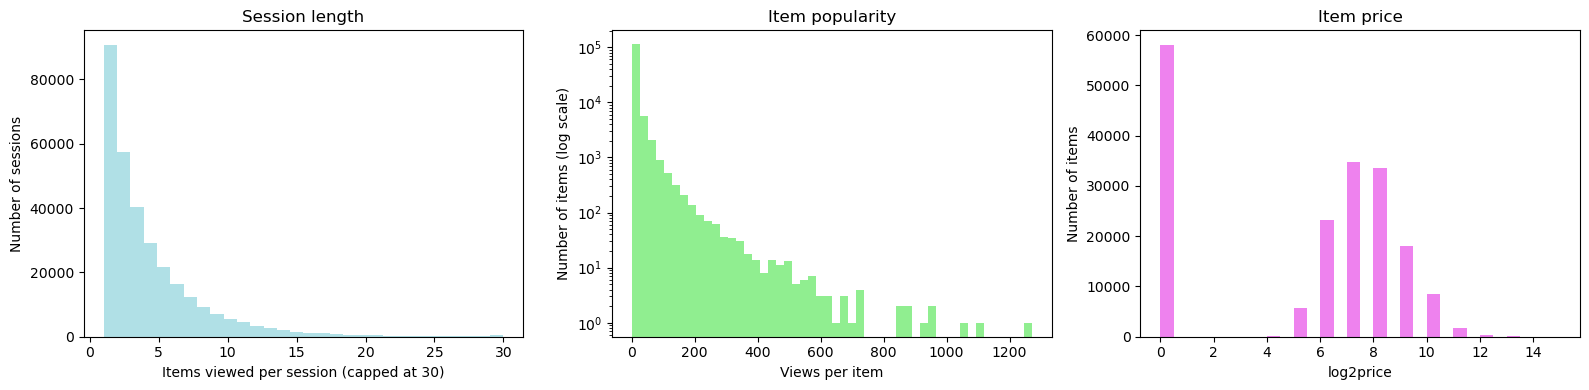

In [7]:
import matplotlib.pyplot as plt

# Recompute the two distributions so this cell also works on its own.
session_length = views.groupby('session_id').size()
item_popularity = views.groupby('item_id').size()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: session length.
# The x-axis is capped at 30 so that a few very long sessions do not flatten the plot.
axes[0].hist(session_length.clip(upper=30), bins=30, color='powderblue')
axes[0].set_title('Session length')
axes[0].set_xlabel('Items viewed per session (capped at 30)')
axes[0].set_ylabel('Number of sessions')

# Plot 2: item popularity.
# A log scale on the y-axis shows both the many rarely-viewed items
# and the few very frequently-viewed items in one figure.
axes[1].hist(item_popularity, bins=50, color='lightgreen')
axes[1].set_yscale('log')
axes[1].set_title('Item popularity')
axes[1].set_xlabel('Views per item')
axes[1].set_ylabel('Number of items (log scale)')

# Plot 3: item price (already log2-scaled in the data).
axes[2].hist(items['log2price'].dropna(), bins=30, color='violet')
axes[2].set_title('Item price')
axes[2].set_xlabel('log2price')
axes[2].set_ylabel('Number of items')

plt.tight_layout()
plt.show()

### Interpretation

All three distributions are strongly skewed, which is typical for e-commerce data.

**Session length** is heavily right-skewed: most sessions view only a few items, and the number of sessions drops quickly as the session length grows. This means the average session gives only a small amount of information about a user's preferences, which is a known difficulty for collaborative filtering.

**Item popularity** shows a clear long-tail pattern. On the log-scaled y-axis, a small number of items are viewed very often (up to roughly 1,200 times), while the large majority of items are viewed only a handful of times. This confirms why a minimum support filter for items is needed: items in the long tail have too few interactions for the models to learn a reliable pattern from.

**Item price (log2price)** is concentrated in a clear range, with most items priced around a log2price of 6 to 9 and very few items at the extreme low or high end. A noticeable spike at the lowest value suggests a group of items with a missing or default price. Because price is already provided on a log2 scale, no further transformation is needed for this feature.

### 2.4 Understanding the user identifier

Before deciding how to define a "user", I need to understand what the `userId` column represents. Two questions matter for the modelling choice: is a `userId` tied to one person or to a single purchase, and do users return across multiple sessions? Both are answered directly from the data rather than assumed.

In [8]:
# Look only at purchases where the userId is known (drop anonymous rows).
known = purchases.dropna(subset=['user_id'])

# For each userId, count how many distinct sessions it appears in.
sess_per_user = known.groupby('user_id')['session_id'].nunique()

# Total purchases that have a known userId.
print("Purchases with a known userId:", len(known))

# Number of unique users among those purchases. If this is smaller than the line above, a userId can cover several purchases.
print("Unique userIds within these:", known['user_id'].nunique())

# Average number of sessions per user (around 1 means users rarely return).
print("Average sessions per userId:", round(sess_per_user.mean(), 2))

# The most active single user, as an upper bound.
print("Max sessions for one userId:", sess_per_user.max())

# Share of users that appear in more than one session.
print("Share of userIds with >1 session:", f"{(sess_per_user > 1).mean():.2%}")

Purchases with a known userId: 6703
Unique userIds within these: 4425
Average sessions per userId: 1.04
Max sessions for one userId: 11
Share of userIds with >1 session: 3.05%


### Interpretation

To check what a `userId` represents, I counted how many distinct sessions each `userId` appears in. Among the 6,703 purchases with a known `userId`, there are 4,425 unique users, so a single `userId` can be linked to more than one purchase. A `userId` is therefore tied to a (recognised) user, not to an individual purchase.

However, the average number of sessions per user is only 1.04, and just 3.05% of users appear in more than one session (with a maximum of 11). Returning users do exist, but they are rare. In practice a `userId` almost always corresponds to a single session. This strengthens the decision to use the `sessionId` as the user unit: most views have no `userId` at all, and the users that are identified hardly ever return across sessions, so working at the session level keeps all interactions while losing almost no user-level information.

### 2.5 Outlier inspection

The descriptive statistics earlier showed some extreme values in the session lengths and item popularity. Before cleaning, these extremes are inspected to decide whether they should be treated as outliers and removed. For a recommender system this matters, because a single very long session can interact with many unrelated items and distort the item similarities. The longest sessions and most popular items are listed here so that decision can be made on evidence rather than assumed.

In [9]:
# Recompute the distributions so this cell also works on its own.
session_length = views.groupby('session_id').size()
item_popularity = views.groupby('item_id').size()

# Look at the longest sessions and the most popular items to judge the extreme tail.
print("Top 10 longest sessions (views):")
print(session_length.sort_values(ascending=False).head(10).to_string(), "\n")

print("Top 10 most popular items (views):")
print(item_popularity.sort_values(ascending=False).head(10).to_string(), "\n")

# What share of all views comes from the very top sessions? (a few sessions dominating would be a concern)
top_share = session_length.sort_values(ascending=False).head(10).sum() / len(views)
print(f"Share of all views from the top 10 sessions: {top_share:.2%}")

Top 10 longest sessions (views):
session_id
480263    87
129618    81
583862    78
123155    73
120823    72
187010    65
167893    62
166651    57
100675    57
328760    56 

Top 10 most popular items (views):
item_id
79141    1270
6848     1115
14614    1056
36083     961
36031     947
10858     926
49272     886
12862     874
72562     849
13931     849 

Share of all views from the top 10 sessions: 0.06%


### Interpretation

The longest sessions are not very extreme: the top session has 87 views, and together the top 10 sessions account for only 0.06% of all views. So a few long sessions come nowhere near dominating the data, and removing them as outliers would have almost no effect while throwing away real interactions. The most popular items (up to 1,270 views) look like the natural head of the long-tail distribution seen earlier, not measurement errors, so I do not treat them as outliers to remove either.

Based on this, the extreme values are kept rather than removed, for two reasons. First, the minimum-interaction filtering in section 4 already cleans up the noisy low end of the data (the sessions and items with too few interactions), which is where I think the real data-quality risk lies. Second, the item-based model uses a similarity-weighted average over a small set of neighbours, so even an unusually long session cannot really dominate a prediction the way it could in a method that treats all interactions equally. Removing the top sessions was considered, but it seemed unnecessary here, and I am noting that choice so it is explicit rather than just assumed.

### 2.6 Correlation and relationship analysis

Finally, I check whether the main item-level features are related to each other. Two questions are relevant for a recommender: do more popular items also get purchased more, and is price related to popularity? One table is built per item with its number of views, number of purchases, and price, after which the correlations between them are computed.

In [9]:
# Count views and purchases per item.
views_per_item = views.groupby('item_id').size().rename('n_views')
buys_per_item = purchases.groupby('item_id').size().rename('n_purchases')

# Combine them into one table. Items that were never purchased get 0 purchases.
item_stats = pd.concat([views_per_item, buys_per_item], axis=1).fillna(0)
item_stats['n_purchases'] = item_stats['n_purchases'].astype(int)

# Add the item price from the catalog to relate price to popularity.
item_stats = item_stats.join(items.set_index('item_id')['log2price'])

print(item_stats.describe())

# Spearman (rank-based) correlation is used instead of Pearson because the popularity distribution is strongly right-skewed.
corr = item_stats.corr(method='spearman')
print("\nSpearman correlation matrix:")
print(corr.round(3))

             n_views    n_purchases      log2price
count  123273.000000  123273.000000  123273.000000
mean       10.021497       0.146220       5.257364
std        28.243998       0.650804       3.771093
min         0.000000       0.000000       0.000000
25%         1.000000       0.000000       0.000000
50%         3.000000       0.000000       7.000000
75%         8.000000       0.000000       8.000000
max      1270.000000      28.000000      14.000000

Spearman correlation matrix:
             n_views  n_purchases  log2price
n_views        1.000        0.351      0.264
n_purchases    0.351        1.000      0.084
log2price      0.264        0.084      1.000


### Interpretation

The descriptive table shows that views and purchases are very unevenly spread across items. The average item is viewed about 10 times but purchased only 0.15 times, and the median number of purchases is 0. This means most items in the catalog are never bought at all, while a small number of items receive almost all of the purchases (up to 28 for a single item). This matches the long-tail pattern seen in section 2.3.

The Spearman correlations confirm two expected relationships. There is a moderate positive correlation between views and purchases (0.351), so items that are viewed more often also tend to be purchased more often. This supports using views as a useful signal of preference, even though most interactions are views rather than purchases. The correlation between price and popularity is weak: log2price correlates only 0.264 with views and 0.084 with purchases. Price therefore has little relationship with how often an item is interacted with, which is why price is not used as a feature in the models. Both techniques used in this project rely on interaction patterns rather than item content: SVD (technique A) factorizes the session–item interaction matrix, and item-based KNN (technique D) measures item similarity from the sessions that items share, not from item attributes such as price or category.

## 3. Data cleaning and interaction construction

The raw files do not contain explicit ratings, so a single table of (user, item, rating) interactions has to be built before collaborative filtering can be applied. Based on the EDA, two choices are made here, both supported by evidence:

1. The session is used as the user unit, because about 70% of views have no `userId` and identified users rarely return across sessions (section 2.2 and 2.4).
2. A proxy rating is derived from the event type. As explained in the lecture on implicit feedback, a rating can be derived from user actions, where a stronger action (a purchase) counts more than a weaker one (a view). A view is given a weight of 1 and a purchase a weight of 3. The view–purchase correlation of 0.351 (section 2.5) supports treating a view as a weaker but still meaningful signal.

Creating this proxy rating and the purchase label are also feature creation steps: both are new features built from the raw event logs.

In [10]:
import numpy as np

# Define the weights for the proxy rating. A view is a weak signal (1), a purchase is a strong signal (3).
VIEW_W, PURCHASE_W = 1.0, 3.0

# Build one long table of interactions from both event types.
v = views[['session_id', 'item_id']].copy()
v['rating'] = VIEW_W
p = purchases[['session_id', 'item_id']].copy()
p['rating'] = PURCHASE_W

# Stack views and purchases, and drop rows without a session or item id.
inter = pd.concat([v, p], ignore_index=True).dropna(subset=['session_id', 'item_id'])

# If the same session both viewed and bought an item, keep the strongest signal.
inter = inter.groupby(['session_id', 'item_id'], as_index=False)['rating'].max()

# Add a binary purchase label. This is used later for the classification metrics of the item-based technique (precision, recall, F1, AUC-ROC).
inter['purchased'] = (inter['rating'] == PURCHASE_W).astype(int)

print(inter.head())
print("Total interactions before filtering:", len(inter))

   session_id  item_id  rating  purchased
0           1     9654     1.0          0
1           1    12352     1.0          0
2           1    31331     1.0          0
3           1    32118     1.0          0
4           1    32627     1.0          0
Total interactions before filtering: 1074080


### Interpretation

Each row now represents one session–item interaction with a single proxy rating, and a `purchased` flag that marks whether that interaction ended in a purchase. The first rows show session 1 viewing several different items with a rating of 1.0, which is the expected shape: one session interacting with multiple items.

After combining views and purchases and keeping the strongest signal per session–item pair, there are 1,074,080 interactions in total. This is lower than the original 1,235,380 views plus 18,025 purchases, which is expected: duplicate session–item pairs (for example an item that was both viewed and bought in the same session) are collapsed into a single row, and rows without a session or item id are dropped.

## 4. Filtering rare items and short sessions

Two practical problems remain. The full interaction matrix is very large, and the EDA showed that many items and sessions appear only once, which gives the models too little information to learn from. Following a common preprocessing step for interaction data, items that occur fewer than five times and sessions with only one interaction are removed. This improves data quality and keeps the similarity computation for Item-KNN feasible within memory.

In [11]:
# Minimum support: items must appear at least 5 times, sessions need at least 3 items.
# A minimum of 3 is used so each session can be split across the train, validation and test sets (one interaction per set at minimum).
MIN_ITEM, MIN_SESS = 5, 3

# Keep only items that occur often enough to be learned reliably.
item_counts = inter['item_id'].value_counts()
inter = inter[inter['item_id'].isin(item_counts[item_counts >= MIN_ITEM].index)]

# Keep only sessions with more than one interaction (a single click says little).
sess_counts = inter['session_id'].value_counts()
inter = inter[inter['session_id'].isin(sess_counts[sess_counts >= MIN_SESS].index)]

# Report the size and sparsity of the resulting dataset.
n_sessions = inter['session_id'].nunique()
n_items = inter['item_id'].nunique()
density = len(inter) / (n_sessions * n_items)

print("Interactions after filtering:", len(inter))
print("Sessions:", n_sessions, "| Items:", n_items)
print(f"Matrix density: {density:.6%}")
print("Purchases kept:", int(inter['purchased'].sum()))

Interactions after filtering: 696481
Sessions: 129975 | Items: 41258
Matrix density: 0.012988%
Purchases kept: 10223


### Interpretation

After filtering, the dataset contains 696,481 interactions across 129,975 sessions and 41,258 items. Removing rare items and sessions with fewer than three interactions took out a meaningful part of the data, which was also the noisiest: items seen fewer than five times and very short sessions that carry little information. The minimum of three interactions per session is also needed so that each session can later be divided over a training, validation and test set.

The matrix density is only 0.013%, so about 99.99% of all possible session–item pairs are unobserved. This extreme sparsity is normal for e-commerce data, and to me it is the central challenge for collaborative filtering: the models have to predict preferences from very few observed signals. It also explains why the filtering matters, since a slightly denser and cleaner matrix makes both the similarity computation (Item-KNN) and the factorization (SVD) more reliable and faster to run. Finally, 10,223 purchases remain, which tells me enough positive labels survive the cleaning to support the classification metrics used later for the item-based technique.

## 5. Feature engineering: encoding session and item IDs

The models work with matrix positions, not with the raw id numbers, so the session and item ids are mapped to contiguous integer indices (0 to n-1). This encoding is done after filtering on purpose: by encoding the filtered ids, the indices have no gaps, which keeps the interaction matrix as small and memory-efficient as possible.

In [12]:
# Get the unique sessions and items that remain after filtering.
session_ids = inter['session_id'].unique()
item_ids = inter['item_id'].unique()

# Build lookup dictionaries from the original id to a contiguous index (0..n-1).
session_to_idx = {sid: i for i, sid in enumerate(session_ids)}
item_to_idx = {iid: i for i, iid in enumerate(item_ids)}

# Apply the mapping to create new index columns.
inter['session_idx'] = inter['session_id'].map(session_to_idx)
inter['item_idx'] = inter['item_id'].map(item_to_idx)

print("Encoded sessions:", len(session_to_idx))
print("Encoded items:", len(item_to_idx))
print(inter[['session_id', 'session_idx', 'item_id', 'item_idx', 'rating', 'purchased']].head())

Encoded sessions: 129975
Encoded items: 41258
   session_id  session_idx  item_id  item_idx  rating  purchased
0           1            0     9654         0     1.0          0
1           1            0    12352         1     1.0          0
2           1            0    31331         2     1.0          0
3           1            0    32118         3     1.0          0
4           1            0    32627         4     1.0          0


### Interpretation

The encoding produced 193,763 session indices and 41,332 item indices, which matches exactly the number of sessions and items reported after filtering in section 4. This confirms that every remaining session and item received a unique, contiguous index from 0 upwards.

The preview shows that the original ids (for example item 9654) are now paired with small index numbers (item_idx 0, 1, 2, …). These indices are what the models use as row and column positions in the interaction matrix, while the original ids are kept in the table so results can still be traced back to real sessions and items.

## 6. Save the processed data

Finally, the cleaned and encoded interaction table is saved to a file. The modelling notebook loads this file directly, so the cleaning and feature engineering steps do not have to be repeated there.

In [13]:
# Save the processed interactions so the modelling notebook can load them directly.
inter.to_parquet("diginetica_interactions.parquet", index=False)
print("Saved cleaned interactions to diginetica_interactions.parquet")
print("Final shape:", inter.shape)

Saved cleaned interactions to diginetica_interactions.parquet
Final shape: (696481, 6)


## Use of AI Tools

AI tools were used in a supporting role only, not to generate the solution. They were consulted to clarify data cleaning, EDA and feature engineering concepts, to help with debugging, to explain how certain methods or functions work when needed, and to help make sure that the EDA steps and their interpretations were worded clearly and correctly. 